# Temporal Evaluation Analysis

This notebook supports the recommender-systems research question: can SVD matrix factorization and KNN collaborative filtering improve both rating prediction and top-k recommendation quality under a time-based validation split?

The official results come from `src/compare_models.py`. This notebook inspects the evidence: data shape, rating distribution, rating activity over time, temporal folds, model metrics, and the final tradeoff. SVD reduces RMSE by 7.4% and MAE by 12.5%, while popularity remains strongest for offline top-k ranking.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "cleaned" / "cleaned_ratings_with_time.csv"
SUMMARY_PATH = PROJECT_ROOT / "reports" / "model_comparison_summary.csv"
FOLD_PATH = PROJECT_ROOT / "reports" / "model_comparison.csv"

plt.style.use("default")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

if not DATA_PATH.exists():
    raise FileNotFoundError("Run `make data` from the project root before this notebook.")
if not SUMMARY_PATH.exists() or not FOLD_PATH.exists():
    raise FileNotFoundError("Run `make evaluate` from the project root before this notebook.")


## Research Design

The evaluation tests three hypotheses:

- H1: SVD and KNNWithMeans reduce RMSE and MAE compared with a global-mean popularity baseline.
- H2: SVD and KNNWithMeans improve precision@10, recall@10, and nDCG@10 compared with popularity ranking.
- H3: Time-based validation gives a more realistic estimate than random splitting because it avoids look-ahead bias.

The positive relevance threshold is `rating >= 4`, and the main recommendation list size is `k=10`.


## 1. Load The Cleaned Data

The cleaned CSV is the common input for research, training, API serving, and the Streamlit app. I keep this as one shared artifact so every part of the project is using the same data definition.


In [2]:
ratings = pd.read_csv(DATA_PATH, parse_dates=["timestamp_datetime"])
ratings.head()


,user_id,item_id,rating,timestamp_unix,timestamp_datetime,rating_year,rating_month,rating_dayofweek,title
0,196,242,3,881250949,1997-12-04 15:55:49,1997,12,3,Kolya (1996)
1,186,302,3,891717742,1998-04-04 19:22:22,1998,4,5,L.A. Confidential (1997)
2,22,377,1,878887116,1997-11-07 07:18:36,1997,11,4,Heavyweights (1994)
3,244,51,2,880606923,1997-11-27 05:02:03,1997,11,3,Legends of the Fall (1994)
4,166,346,1,886397596,1998-02-02 05:33:16,1998,2,0,Jackie Brown (1997)


In [3]:
summary = pd.DataFrame({
    "rows": [len(ratings)],
    "users": [ratings["user_id"].nunique()],
    "movies": [ratings["item_id"].nunique()],
    "first_rating": [ratings["timestamp_datetime"].min()],
    "last_rating": [ratings["timestamp_datetime"].max()],
    "mean_rating": [ratings["rating"].mean()],
})
summary


,rows,users,movies,first_rating,last_rating,mean_rating
0,100000,943,1682,1997-09-20 03:05:10,1998-04-22 23:10:38,3.52986


## 2. Rating Distribution

This graph shows the target variable. MovieLens ratings are not perfectly balanced: users tend to give many 3, 4, and 5 star ratings. This matters because the model sees more positive feedback than negative feedback.


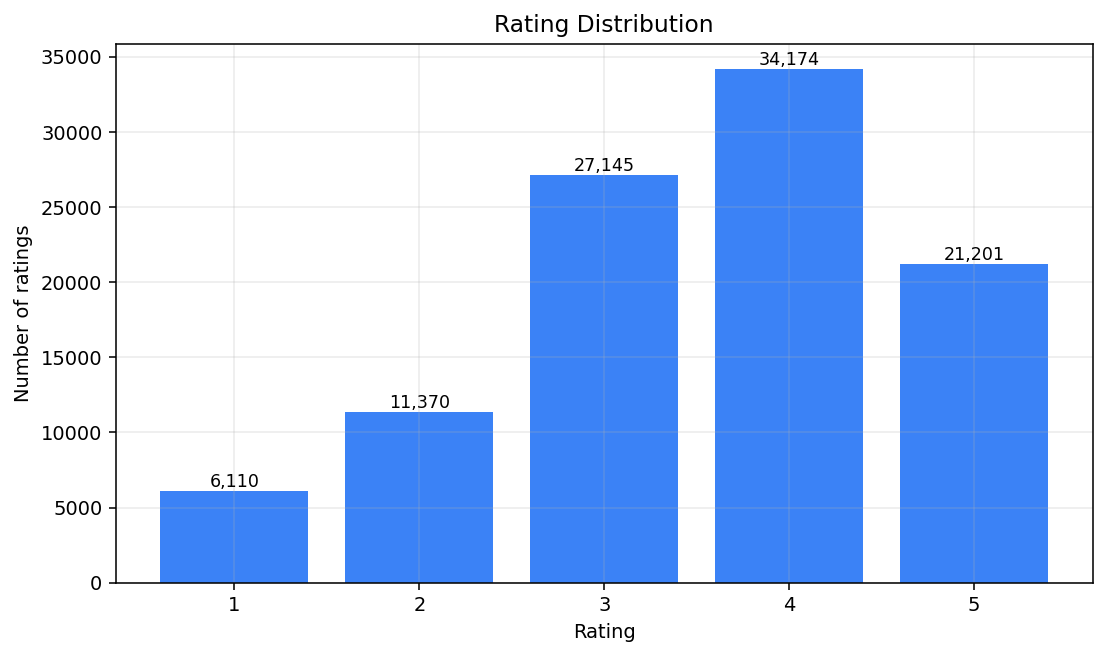

In [4]:
rating_counts = ratings["rating"].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(rating_counts.index.astype(str), rating_counts.values, color="#3B82F6")
ax.set_title("Rating Distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of ratings")
for idx, value in enumerate(rating_counts.values):
    ax.text(idx, value, f"{value:,}", ha="center", va="bottom", fontsize=9)
plt.show()


## 3. Ratings Over Time

The timestamps make temporal validation possible. I do not want the model to learn from future ratings when testing on earlier behavior, so the final evaluation sorts by time and uses expanding windows.


<notebook-cell>:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.


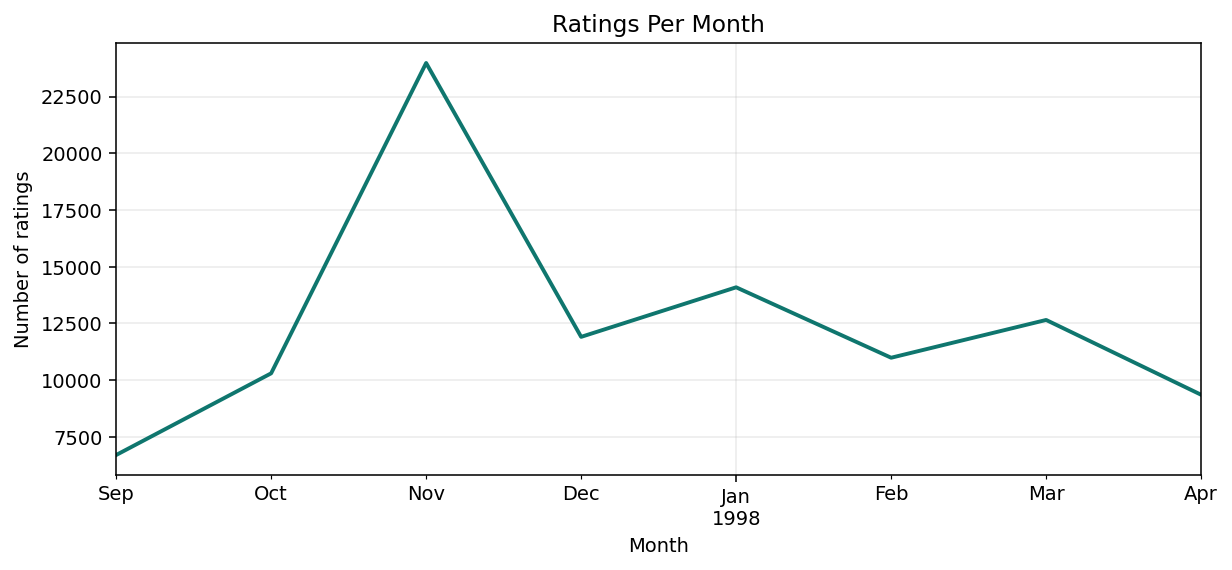

In [5]:
monthly = (
    ratings.set_index("timestamp_datetime")
    .resample("M")
    .size()
    .rename("ratings")
)

fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(ax=ax, color="#0F766E", linewidth=2)
ax.set_title("Ratings Per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of ratings")
plt.show()


## 4. Sparsity And Activity

Recommender data is sparse: every user rates only a small subset of the catalog. These two histograms show how uneven the activity is across users and movies.


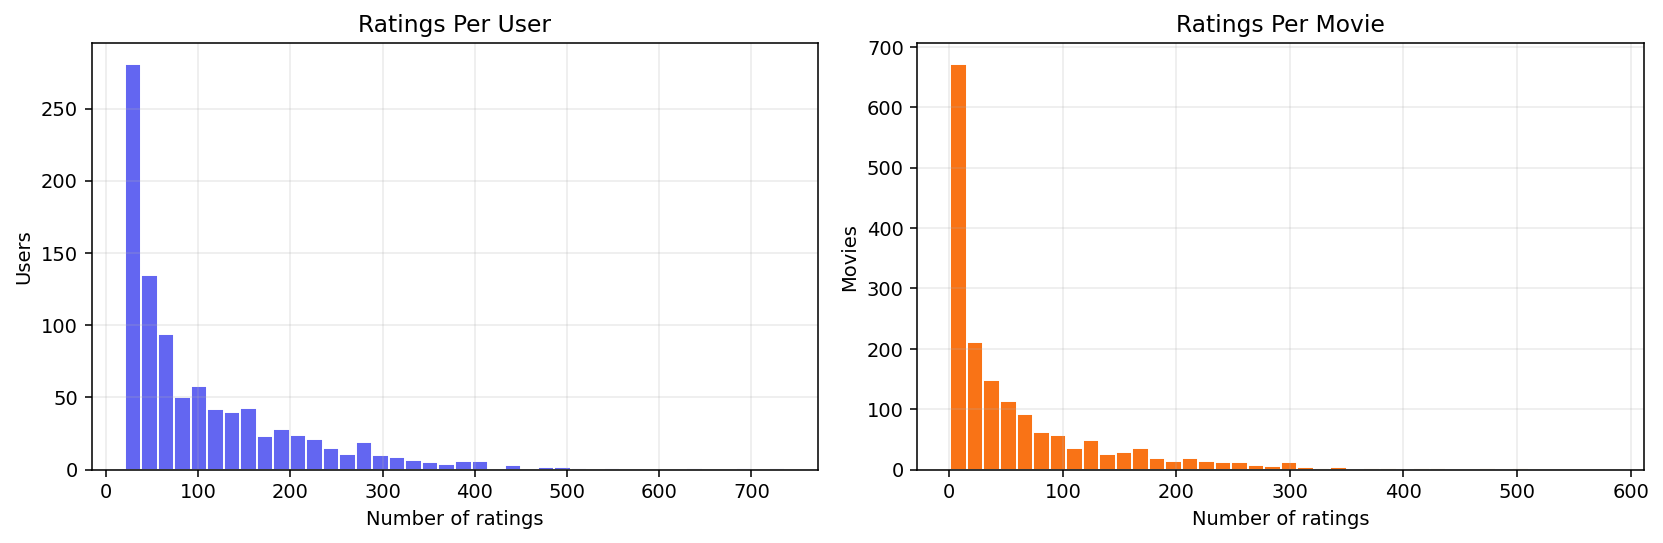

In [6]:
user_activity = ratings.groupby("user_id").size()
movie_activity = ratings.groupby("item_id").size()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(user_activity, bins=40, color="#6366F1", edgecolor="white")
axes[0].set_title("Ratings Per User")
axes[0].set_xlabel("Number of ratings")
axes[0].set_ylabel("Users")

axes[1].hist(movie_activity, bins=40, color="#F97316", edgecolor="white")
axes[1].set_title("Ratings Per Movie")
axes[1].set_xlabel("Number of ratings")
axes[1].set_ylabel("Movies")

plt.tight_layout()
plt.show()


## 5. Temporal Fold Shape

This table shows the expanding-window idea in code. Each test period is later than its training period. That is the main methodological upgrade over a random split.


In [7]:
from src.evaluation import temporal_expanding_splits

fold_rows = []
for fold in temporal_expanding_splits(ratings, n_splits=5, timestamp_col="timestamp_unix"):
    fold_rows.append({
        "fold": fold.fold,
        "train_rows": len(fold.train),
        "test_rows": len(fold.test),
        "train_start": fold.train["timestamp_datetime"].min(),
        "train_end": fold.train["timestamp_datetime"].max(),
        "test_start": fold.test["timestamp_datetime"].min(),
        "test_end": fold.test["timestamp_datetime"].max(),
    })
folds = pd.DataFrame(fold_rows)
folds


,fold,train_rows,test_rows,train_start,train_end,test_start,test_end
0,1,16666,16666,1997-09-20 03:05:10,1997-10-30 01:47:27,1997-10-30 01:47:27,1997-11-20 02:40:29
1,2,33332,16666,1997-09-20 03:05:10,1997-11-20 02:40:29,1997-11-20 02:40:29,1997-12-22 21:41:55
2,3,49998,16666,1997-09-20 03:05:10,1997-12-22 21:41:55,1997-12-22 21:42:24,1998-01-30 19:03:32
3,4,66664,16666,1997-09-20 03:05:10,1998-01-30 19:03:32,1998-01-30 19:10:14,1998-03-25 21:11:30
4,5,83330,16670,1997-09-20 03:05:10,1998-03-25 21:11:30,1998-03-25 21:11:30,1998-04-22 23:10:38


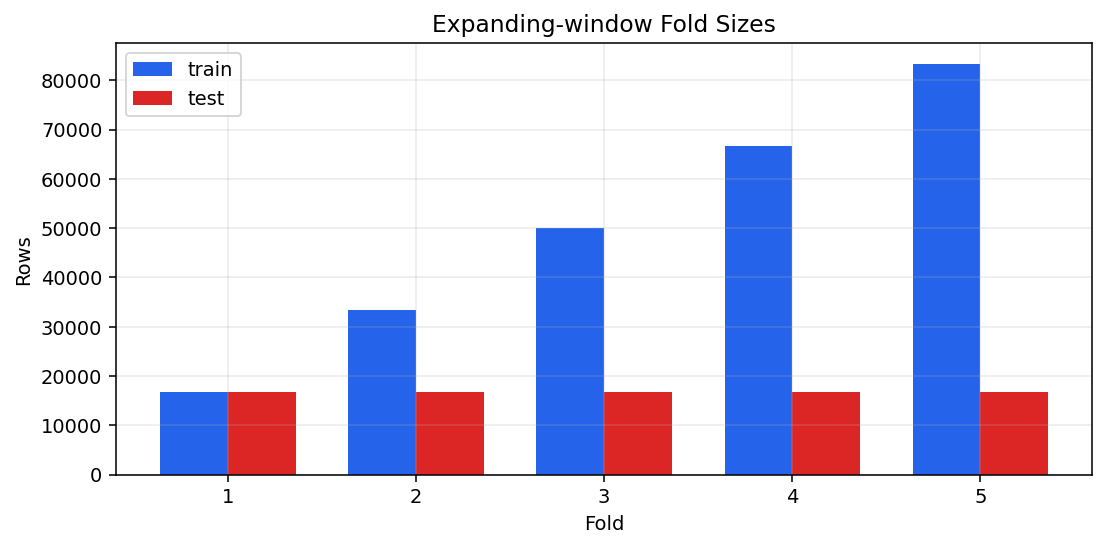

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(folds["fold"] - 0.18, folds["train_rows"], width=0.36, label="train", color="#2563EB")
ax.bar(folds["fold"] + 0.18, folds["test_rows"], width=0.36, label="test", color="#DC2626")
ax.set_title("Expanding-window Fold Sizes")
ax.set_xlabel("Fold")
ax.set_ylabel("Rows")
ax.legend()
plt.show()


## 6. Final Model Comparison

These are the canonical results from `reports/model_comparison_summary.csv`. Lower is better for RMSE and MAE. Higher is better for precision, recall, nDCG, and coverage.


In [9]:
summary = pd.read_csv(SUMMARY_PATH)
label_map = {
    "popularity_baseline": "Popularity",
    "knn_with_means": "KNNWithMeans",
    "svd": "SVD",
}
summary["label"] = summary["model_name"].map(label_map)
summary[[
    "label", "rmse_mean", "mae_mean", "precision_at_10_mean",
    "recall_at_10_mean", "ndcg_at_10_mean", "coverage_at_10_mean"
]].round(4)


,label,rmse_mean,mae_mean,precision_at_10_mean,recall_at_10_mean,ndcg_at_10_mean,coverage_at_10_mean
0,KNNWithMeans,1.1146,0.9251,0.0845,0.0178,0.0972,0.0574
1,Popularity,1.1317,0.9474,0.1978,0.0581,0.1931,0.0268
2,SVD,1.0485,0.8288,0.1707,0.0456,0.1614,0.0822


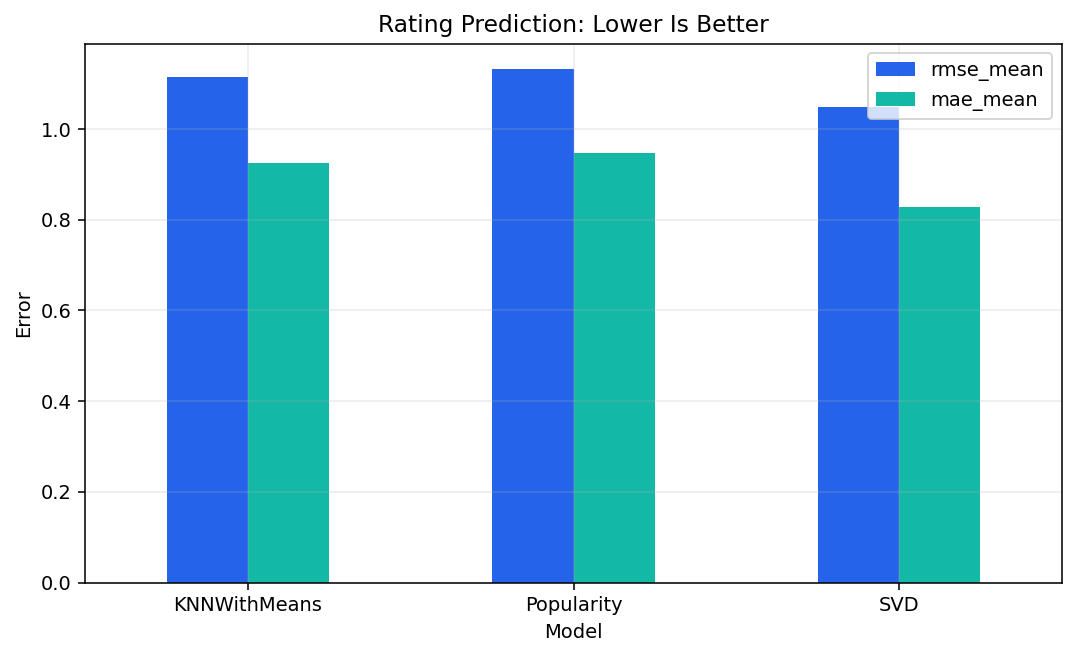

In [10]:
prediction_metrics = summary.set_index("label")[["rmse_mean", "mae_mean"]]

fig, ax = plt.subplots()
prediction_metrics.plot(kind="bar", ax=ax, color=["#2563EB", "#14B8A6"])
ax.set_title("Rating Prediction: Lower Is Better")
ax.set_xlabel("Model")
ax.set_ylabel("Error")
ax.tick_params(axis="x", rotation=0)
plt.show()


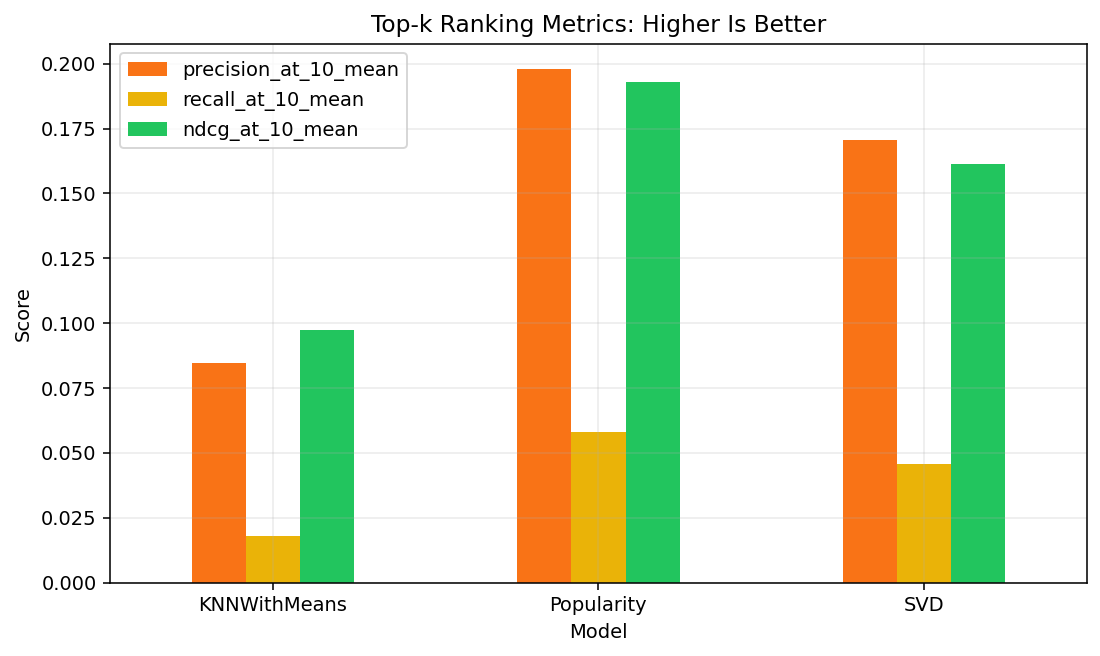

In [11]:
ranking_metrics = summary.set_index("label")[[
    "precision_at_10_mean", "recall_at_10_mean", "ndcg_at_10_mean"
]]

fig, ax = plt.subplots()
ranking_metrics.plot(kind="bar", ax=ax, color=["#F97316", "#EAB308", "#22C55E"])
ax.set_title("Top-k Ranking Metrics: Higher Is Better")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.tick_params(axis="x", rotation=0)
plt.show()


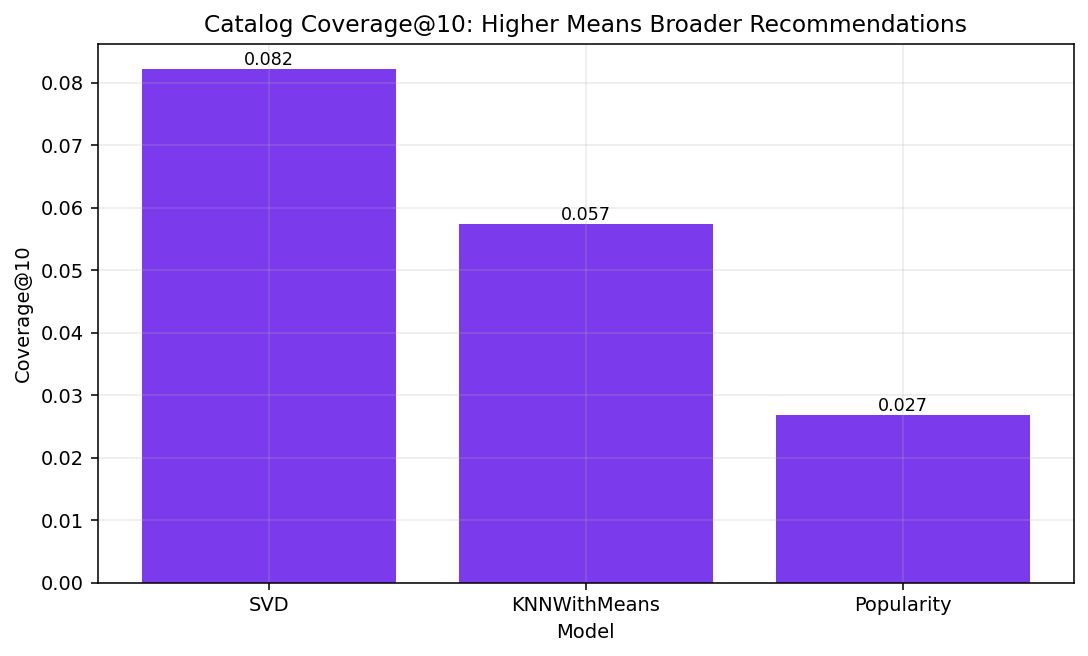

In [12]:
coverage = summary.set_index("label")["coverage_at_10_mean"].sort_values(ascending=False)

fig, ax = plt.subplots()
ax.bar(coverage.index, coverage.values, color="#7C3AED")
ax.set_title("Catalog Coverage@10: Higher Means Broader Recommendations")
ax.set_xlabel("Model")
ax.set_ylabel("Coverage@10")
for idx, value in enumerate(coverage.values):
    ax.text(idx, value, f"{value:.3f}", ha="center", va="bottom", fontsize=9)
plt.show()


## 7. Fold-level Stability

The summary is useful, but the fold-level plot shows whether a result is stable or caused by one fold. SVD stays strongest for RMSE across the temporal folds.


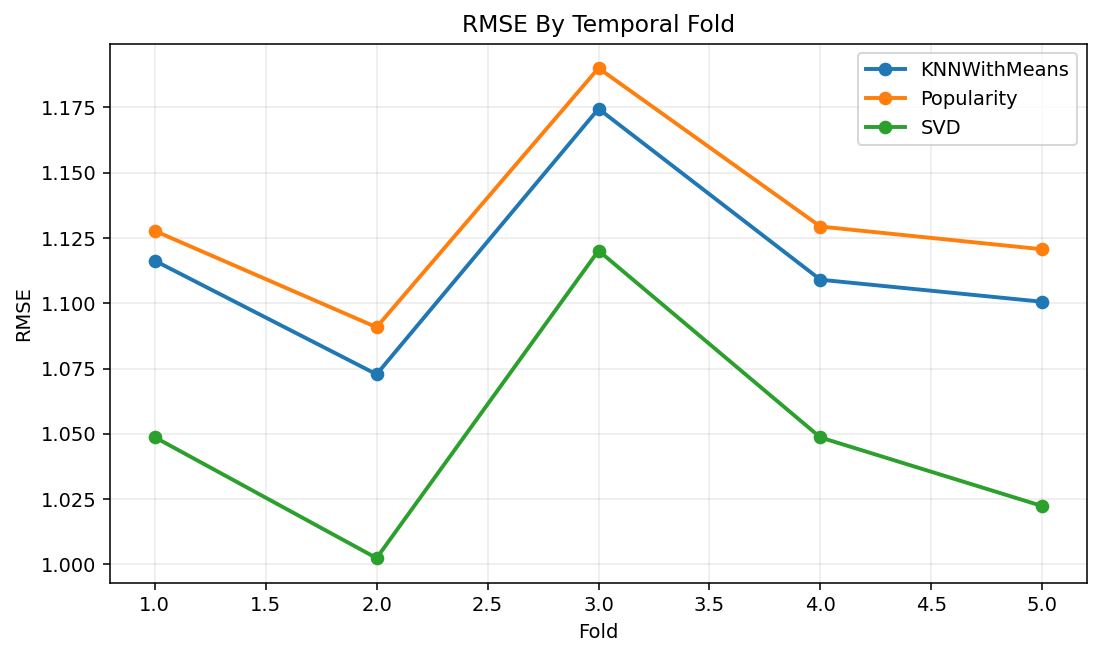

In [13]:
fold_results = pd.read_csv(FOLD_PATH)
fold_results["label"] = fold_results["model_name"].map(label_map)

fig, ax = plt.subplots(figsize=(9, 5))
for label, group in fold_results.groupby("label"):
    group = group.sort_values("fold")
    ax.plot(group["fold"], group["rmse"], marker="o", linewidth=2, label=label)
ax.set_title("RMSE By Temporal Fold")
ax.set_xlabel("Fold")
ax.set_ylabel("RMSE")
ax.legend()
plt.show()


## 8. Research Interpretation

The visual result matches the research interpretation: SVD is best for rating prediction, popularity is strongest for the current offline top-k metrics, and SVD gives broader catalog coverage. This is the main methodological point of the project: recommender systems need several metrics because each metric answers a different question.
